In [4]:
"""
Wildfire Disturbance & Vegetation Regeneration Rate Modeling
-----------------------------------------------------------
Quantifies ecosystem recovery trajectories by comparing pixel-level 
spectral dynamics (NDVI & NBR) between burned perimeters and 
unburned control regions over a 2-year window (2020-2022).
"""

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load processed spectral raster cube
cube_path = "../data/processed/august_complex_spectral_cube.nc"
ds = xr.open_dataset(cube_path)

print("[+] Spectral Data Cube loaded successfully.")
print(f"    Available variables: {list(ds.data_vars.keys())}")
print(f"    Timepoints: {[str(t)[:10] for t in ds['time'].values]}")

[+] Spectral Data Cube loaded successfully.
    Available variables: ['dNBR', 'B04', 'B08', 'B12', 'NDVI', 'NBR']
    Timepoints: ['2020-07-20', '2020-10-15', '2021-07-20', '2022-07-20']


In [5]:
# ==========================================
# 1. Pixel-Level Segmentation (Burned vs Control)
# ==========================================
# Extract Delta NBR (Burn Severity)
dnbr = ds["dNBR"]

# Classify spatial pixels into Burned Perimeter vs Unburned Control
burned_mask = dnbr > 0.4      # Moderate to High Severity Burn (dNBR > 0.4)
unburned_mask = dnbr <= 0.1   # Unburned / Low Disturbance Control (dNBR <= 0.1)

print(f"[*] Total pixels analyzed: {dnbr.size}")
print(f"[*] Burned Perimeter pixels: {int(burned_mask.sum())} ({float(burned_mask.mean()) * 100:.1f}% of AOI)")
print(f"[*] Control Region pixels: {int(unburned_mask.sum())} ({float(unburned_mask.mean()) * 100:.1f}% of AOI)")

# ==========================================
# 2. Extract Spectral Trajectories (2020-2022)
# ==========================================
trajectory_records = []
dates = ds["time"].values

for t in dates:
    date_str = str(t)[:10]
    
    # Slice arrays at time t
    ndvi_t = ds["NDVI"].sel(time=t)
    nbr_t = ds["NBR"].sel(time=t)
    
    # Calculate spatial mean for burned vs control regions
    b_ndvi = float(ndvi_t.where(burned_mask).mean())
    u_ndvi = float(ndvi_t.where(unburned_mask).mean())
    
    b_nbr = float(nbr_t.where(burned_mask).mean())
    u_nbr = float(nbr_t.where(unburned_mask).mean())
    
    trajectory_records.append({
        "Date": date_str,
        "Burned_NDVI": b_ndvi,
        "Control_NDVI": u_ndvi,
        "Burned_NBR": b_nbr,
        "Control_NBR": u_nbr
    })

df_traj = pd.DataFrame(trajectory_records)

# Calculate 2-Year Vegetation Recovery Index (VRI %)
pre_nbr = df_traj.loc[df_traj["Date"] == "2020-07-20", "Burned_NBR"].values[0]
post_nbr = df_traj.loc[df_traj["Date"] == "2020-10-15", "Burned_NBR"].values[0]

df_traj["Recovery_VRI_Pct"] = np.maximum(0, (df_traj["Burned_NBR"] - post_nbr) / (pre_nbr - post_nbr) * 100)

print("\n[+] Ecosystem Trajectory & Recovery Summary:")
print(df_traj.to_string(index=False))

# Export trajectory summary to CSV
df_traj.to_csv("../data/processed/recovery_trajectories.csv", index=False)
print("\n[+] Exported trajectory metrics to ../data/processed/recovery_trajectories.csv")

[*] Total pixels analyzed: 90000
[*] Burned Perimeter pixels: 17714 (19.7% of AOI)
[*] Control Region pixels: 72286 (80.3% of AOI)

[+] Ecosystem Trajectory & Recovery Summary:
      Date  Burned_NDVI  Control_NDVI  Burned_NBR  Control_NBR  Recovery_VRI_Pct
2020-07-20     0.775669      0.776047    0.451699     0.452275        100.000000
2020-10-15    -0.105590      0.776047   -0.559246     0.452275          0.000000
2021-07-20     0.286308      0.776047   -0.069508     0.452275         48.443635
2022-07-20     0.425690      0.776047    0.224790     0.452275         77.554735

[+] Exported trajectory metrics to ../data/processed/recovery_trajectories.csv


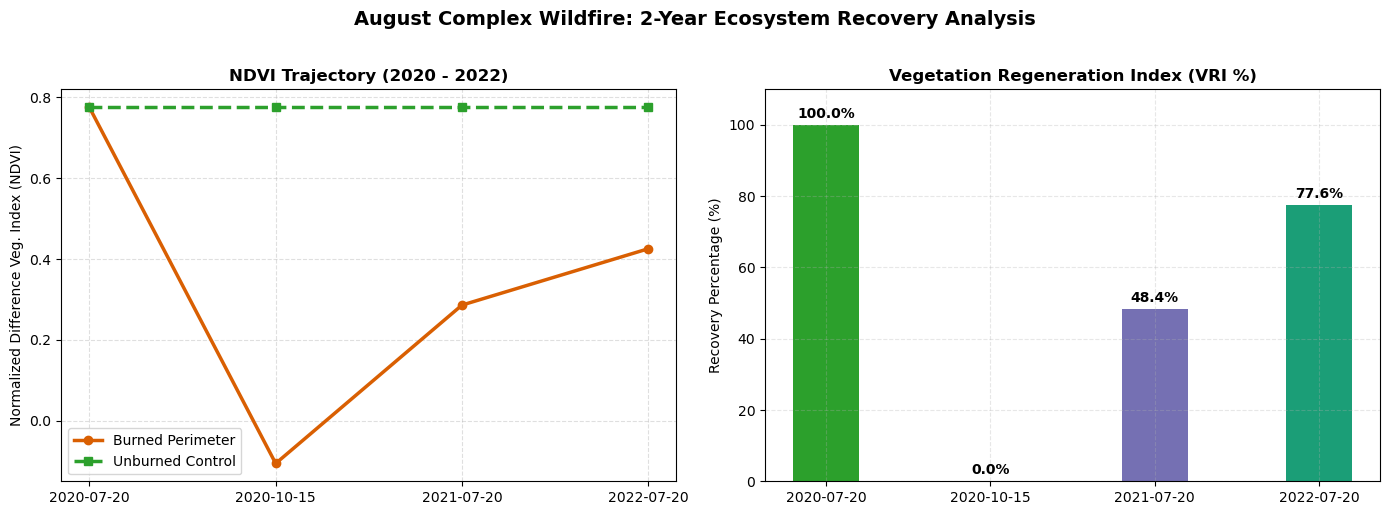

In [6]:
# ==========================================
# 3. Plot Vegetation Regeneration Trajectories
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: NDVI Recovery Trajectory
ax1.plot(df_traj["Date"], df_traj["Burned_NDVI"], 'o-', color='#d95f02', linewidth=2.5, label='Burned Perimeter')
ax1.plot(df_traj["Date"], df_traj["Control_NDVI"], 's--', color='#2ca02c', linewidth=2.5, label='Unburned Control')
ax1.set_title("NDVI Trajectory (2020 - 2022)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Normalized Difference Veg. Index (NDVI)")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend()

# Subplot 2: Vegetation Recovery Index (VRI %)
ax2.bar(df_traj["Date"], df_traj["Recovery_VRI_Pct"], color=['#2ca02c', '#d95f02', '#7570b3', '#1b9e77'], width=0.4)
ax2.set_title("Vegetation Regeneration Index (VRI %)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Recovery Percentage (%)")
ax2.set_ylim(0, 110)
for i, val in enumerate(df_traj["Recovery_VRI_Pct"]):
    ax2.text(i, val + 2, f"{val:.1f}%", ha='center', fontweight='bold')
ax2.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("August Complex Wildfire: 2-Year Ecosystem Recovery Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()